# Bronze Layer — Drug Delivery Dataset (Master_Sheet)
---
**Objective:** Read and save the raw `Master_Sheet` data exactly as is, without any modification (no cleaning, no renaming, no standardization).

**Environment:** Google Colab

**Input:** `Drug_Delivery_Dataset.xlsx` -> Sheet: `Master_Sheet`

**Output:** `Bronze_Layer/DrugDelivery_Bronze.csv`

## 1. Imports & Setup

In [1]:
#1. Install necessary libraries
import subprocess
subprocess.run(["pip", "install", "openpyxl", "--quiet"])

import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import os

os.makedirs("Bronze_Layer", exist_ok=True)
print("Libraries imported | Bronze_Layer folder ready")

Libraries imported | Bronze_Layer folder ready


In [2]:
# 2. Configure pandas display settings
pd.options.display.max_rows = None
pd.options.display.max_columns = None

## 2. Load Raw Data — Master_Sheet

In [16]:
# 3. Load the raw Excel file -> Master_Sheet only
# If uploaded directly to Colab session:
file_path = "/content/Drug_Delivery_Dataset.xlsx"
# If stored on Google Drive, use the full path instead, e.g.:
# file_path = "/content/drive/MyDrive/<your_folder>/Drug_Delivery_Dataset.xlsx"

df_bronze = pd.read_excel(file_path, sheet_name="Master_Sheet")

print(f"Shape: {df_bronze.shape[0]:,} rows | {df_bronze.shape[1]} columns")
df_bronze.head(3)

Shape: 2,374 rows | 27 columns


,NPs ID,NP_Class,INPs_Core,Targeting Strategy,Shape,PDI,Size (nm),Size_Category,Zeta Potential (mv),Zeta_Category,Responsive release,Tumor Cell,Tumor Site,Tumor Size ( mm³),Administration Dosages (mg/kg),Organ or tissue,Time point (h),Biodistribution (%ID),Tumor_%ID,Liver_%ID,Tumor selectivity,Selectivity_Index,Targeting_Efficiency,Shell Type,MW Shell,HAS_PEG,Spleen_%ID
0,INPs-P1,Inorganic,Gold,Active,Rod,NaN,37.50,Optimal Range,-18.00,Negative,No,HeLa cell,Cervix,100.00,20.00,Tumor,6.00,1.64,1.64,29.03,NaN,0.05,Moderate,PEG,4441,Yes,2.76
1,INPs-P1,Inorganic,Gold,Active,Rod,NaN,37.50,Optimal Range,-18.00,Negative,No,HeLa cell,Cervix,100.00,20.00,Tumor,24.00,2.06,2.06,31.70,NaN,0.06,Moderate,PEG,4441,Yes,3.05
2,INPs-P1,Inorganic,Gold,Active,Rod,NaN,37.50,Optimal Range,-18.00,Negative,No,HeLa cell,Cervix,100.00,20.00,Tumor,168.00,2.01,2.01,21.74,NaN,0.08,Moderate,PEG,4441,Yes,2.47


## 3. Column Overview

In [17]:
print("Columns")
print(df_bronze.columns.tolist())

Columns
['NPs ID', 'NP_Class', 'INPs_Core', 'Targeting Strategy', 'Shape', 'PDI', 'Size (nm)', 'Size_Category', 'Zeta Potential (mv)', ' Zeta_Category', 'Responsive release', 'Tumor Cell', 'Tumor Site', 'Tumor Size ( mm³)', 'Administration Dosages (mg/kg)', 'Organ or tissue', 'Time point (h)', 'Biodistribution (%ID)', 'Tumor_%ID', 'Liver_%ID', 'Tumor selectivity', 'Selectivity_Index', 'Targeting_Efficiency', 'Shell Type', 'MW Shell', 'HAS_PEG', 'Spleen_%ID']


In [19]:
print("Data Types")
print(df_bronze.dtypes.to_string())

Data Types
NPs ID                             object
NP_Class                           object
INPs_Core                          object
Targeting Strategy                 object
Shape                              object
PDI                               float64
Size (nm)                         float64
Size_Category                      object
Zeta Potential (mv)               float64
 Zeta_Category                     object
Responsive release                 object
Tumor Cell                         object
Tumor Site                         object
Tumor Size ( mm³)                 float64
Administration Dosages (mg/kg)    float64
Organ or tissue                    object
Time point (h)                    float64
Biodistribution (%ID)             float64
Tumor_%ID                         float64
Liver_%ID                         float64
Tumor selectivity                 float64
Selectivity_Index                 float64
Targeting_Efficiency               object
Shell Type             

In [6]:
#Data Info
df_bronze.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2374 entries, 0 to 2373
Data columns (total 27 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   NPs ID                          2374 non-null   object 
 1   NP_Class                        2374 non-null   object 
 2   INPs_Core                       1375 non-null   object 
 3   Targeting Strategy              2374 non-null   object 
 4   Shape                           2374 non-null   object 
 5   PDI                             1002 non-null   float64
 6   Size (nm)                       2374 non-null   float64
 7   Size_Category                   2374 non-null   object 
 8   Zeta Potential (mv)             1763 non-null   float64
 9    Zeta_Category                  1763 non-null   object 
 10  Responsive release              2374 non-null   object 
 11  Tumor Cell                      2374 non-null   object 
 12  Tumor Site                      23

In [7]:
#Data Description
df_bronze.describe()

,PDI,Size (nm),Zeta Potential (mv),Tumor Size ( mm³),Administration Dosages (mg/kg),Time point (h),Biodistribution (%ID),Tumor_%ID,Liver_%ID,Tumor selectivity,Selectivity_Index,Spleen_%ID
count,"1,002.00","2,374.00","1,763.00","2,172.00","2,119.00","2,374.00","2,374.00","2,374.00","2,374.00","1,728.00","2,374.00","2,374.00"
mean,0.35,74.98,-8.23,469.67,12.37,19.19,5.13,1.31,17.16,0.46,0.30,2.30
std,0.51,60.57,13.01,966.51,22.38,35.20,11.86,2.38,19.22,0.50,0.87,6.87
min,0.02,1.40,-43.00,50.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.12,18.00,-19.60,100.00,3.75,2.00,0.19,0.19,2.90,0.00,0.02,0.15
50%,0.20,64.21,-4.00,100.00,5.00,6.00,0.69,0.52,9.48,0.00,0.05,0.46
75%,0.20,110.00,0.00,270.00,11.00,24.00,3.68,1.28,24.28,1.00,0.14,1.72
max,1.90,225.20,18.70,"4,170.00",180.00,336.00,95.07,22.28,93.64,1.00,7.22,95.07


## 4. Missing Values Analysis

In [20]:
missing = (df_bronze.isnull().sum() / len(df_bronze) * 100).round(2)
missing = missing[missing > 0].sort_values(ascending=False)
print(f"Columns with missing values: {len(missing)}")
print((missing.astype(str) + " %").to_string())

Columns with missing values: 7
PDI                               57.79 %
INPs_Core                         42.08 %
Tumor selectivity                 27.21 %
Zeta Potential (mv)               25.74 %
 Zeta_Category                    25.74 %
Administration Dosages (mg/kg)    10.74 %
Tumor Size ( mm³)                  8.51 %


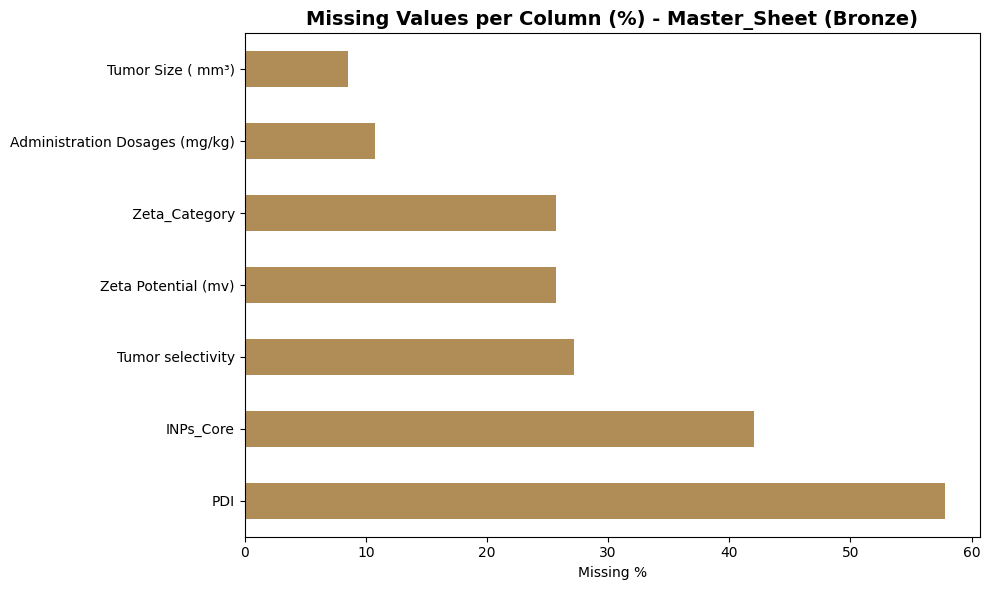

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
missing.plot(kind="barh", color="#B08D57", ax=ax)
ax.set_title("Missing Values per Column (%) - Master_Sheet (Bronze)", fontsize=14, fontweight="bold")
ax.set_xlabel("Missing %")
plt.tight_layout(); plt.show(); plt.close()

### 5. Duplicate Rows Check (info only — no removal in Bronze)

In [10]:
print(f"Duplicate rows: {df_bronze.duplicated().sum()}")
print(f"Unique NPs ID: {df_bronze['NPs ID'].nunique()}")

Duplicate rows: 0
Unique NPs ID: 84


### 6. Save Bronze Layer

In [11]:
#Save data as CSV in Bronze file (Data As Is)
df_bronze.to_csv("Bronze_Layer/DrugDelivery_Bronze.csv", index=False)

print(f"Saved: Bronze_Layer/DrugDelivery_Bronze.csv")
print(f"Rows: {df_bronze.shape[0]:,} | Columns: {df_bronze.shape[1]}")

Saved: Bronze_Layer/DrugDelivery_Bronze.csv
Rows: 2,374 | Columns: 27


### *7*. Download Bronze Layer file

In [14]:
from google.colab import files
files.download("Bronze_Layer/DrugDelivery_Bronze.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>